**Mount Drive (Colab)**

In [ ]:
from google.colab import drive
drive.mount('/content/drive/')

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


**Dataset Loading and Inspection**

In [ ]:
import pandas as pd

zoo_data = pd.read_csv('drive/MyDrive/Datasets For ML/zoo.csv')
class_data = pd.read_csv('drive/MyDrive/Datasets For ML/class.csv')

print("Zoo Shape:", zoo_data.shape)
print("Class Shape:", class_data.shape)

print("\nZoo First 2 Rows:\n", zoo_data.head(2))
print("\nClass File:\n", class_data)

Zoo Shape: (101, 18)
Class Shape: (7, 4)

Zoo First 2 Rows:
   animal_name  hair  feathers  eggs  milk  airborne  aquatic  predator  \
0    aardvark     1         0     0     1         0        0         1   
1    antelope     1         0     0     1         0        0         0   

   toothed  backbone  breathes  venomous  fins  legs  tail  domestic  catsize  \
0        1         1         1         0     0     4     0         0        1   
1        1         1         1         0     0     4     1         0        1   

   class_type  
0           1  
1           1  

Class File:
    Class_Number  Number_Of_Animal_Species_In_Class    Class_Type  \
0             1                                 41        Mammal   
1             2                                 20          Bird   
2             3                                  5       Reptile   
3             4                                 13          Fish   
4             5                                  4     Amphibian   
5 

**Merge Class Labels**

zoo.csv contains type column (1–7).
We merge to get actual class names.

In [ ]:
zoo_data = zoo_data.merge(
    class_data,
    left_on="class_type",
    right_on="Class_Number"
)

zoo_data.head(2)

,animal_name,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,...,fins,legs,tail,domestic,catsize,class_type,Class_Number,Number_Of_Animal_Species_In_Class,Class_Type,Animal_Names
0,aardvark,1,0,0,1,0,0,1,1,1,...,0,4,0,0,1,1,1,41,Mammal,"aardvark, antelope, bear, boar, buffalo, calf,..."
1,antelope,1,0,0,1,0,0,0,1,1,...,0,4,1,0,1,1,1,41,Mammal,"aardvark, antelope, bear, boar, buffalo, calf,..."


In [ ]:
print("Duplicated:", zoo_data.duplicated().sum())
print("Missing:\n", zoo_data.isna().sum())

Duplicated: 0
Missing:
 animal_name                          0
hair                                 0
feathers                             0
eggs                                 0
milk                                 0
airborne                             0
aquatic                              0
predator                             0
toothed                              0
backbone                             0
breathes                             0
venomous                             0
fins                                 0
legs                                 0
tail                                 0
domestic                             0
catsize                              0
class_type                           0
Class_Number                         0
Number_Of_Animal_Species_In_Class    0
Class_Type                           0
Animal_Names                         0
dtype: int64


**Drop Unnecessary Columns**

In [ ]:
zoo_data.shape

(101, 22)

In [ ]:
zoo_data.drop(["animal_name", "Class_Number"], axis=1, inplace=True)
zoo_data.shape

(101, 20)

**Feature–Target Split**

In [ ]:
X = zoo_data.drop(["class_type", "Class_Type", "Animal_Names"], axis=1)
y = zoo_data["Class_Type"]   # multi-class target

**Train-Test Split**

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

**Multi-Class AdaBoost (Decision Stumps)**

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier

stump = DecisionTreeClassifier(max_depth=1, random_state=42)

ada_model = AdaBoostClassifier(
    estimator=stump,
    n_estimators=100,
    learning_rate=1.0,
    algorithm="SAMME",   # Required for multi-class
    random_state=42
)

ada_model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


AdaBoostClassifier(algorithm='SAMME',
                   estimator=DecisionTreeClassifier(max_depth=1,
                                                    random_state=42),
                   n_estimators=100, random_state=42)

**Model Evaluation**

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = ada_model.predict(X_test)

print("Training Accuracy:", accuracy_score(y_train, ada_model.predict(X_train)))
print("Testing Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

Training Accuracy: 0.925
Testing Accuracy: 0.9047619047619048

Classification Report:

              precision    recall  f1-score   support

   Amphibian       1.00      1.00      1.00         1
        Bird       1.00      1.00      1.00         4
         Bug       0.00      0.00      0.00         2
        Fish       1.00      1.00      1.00         3
Invertebrate       0.50      1.00      0.67         2
      Mammal       1.00      1.00      1.00         8
     Reptile       1.00      1.00      1.00         1

    accuracy                           0.90        21
   macro avg       0.79      0.86      0.81        21
weighted avg       0.86      0.90      0.87        21


Confusion Matrix:

[[1 0 0 0 0 0 0]
 [0 4 0 0 0 0 0]
 [0 0 0 0 2 0 0]
 [0 0 0 3 0 0 0]
 [0 0 0 0 2 0 0]
 [0 0 0 0 0 8 0]
 [0 0 0 0 0 0 1]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


**Weak Learners**

Each estimator is a decision stump.

In [ ]:
print("Number of Weak Learners:", len(ada_model.estimators_))

Number of Weak Learners: 100


**Learner Weights (Alpha Values)**

In [ ]:
alpha_values = ada_model.estimator_weights_

print("First 10 Alpha Values:")
print(alpha_values[:10])

First 10 Alpha Values:
[2.24959256 1.78254281 1.67892694 1.77629207 1.54591019 1.45341943
 1.78799193 1.52426904 1.82791831 1.70224171]


In multi-class AdaBoost (SAMME):

𝛼
𝑡
=
ln
⁡
(
1
−
𝑒
𝑟
𝑟
𝑜
𝑟
𝑡
𝑒
𝑟
𝑟
𝑜
𝑟
𝑡
)
+
ln
(
𝐾
−
1
)
α
t

=ln(
error
t
1−error
t

)+ln(K−1)

Where:

𝐾
K = number of classes (7 here)

𝑒
𝑟
𝑟
𝑜
𝑟
𝑡
error
t
	​

 = stump error

**Plot Alpha Values**

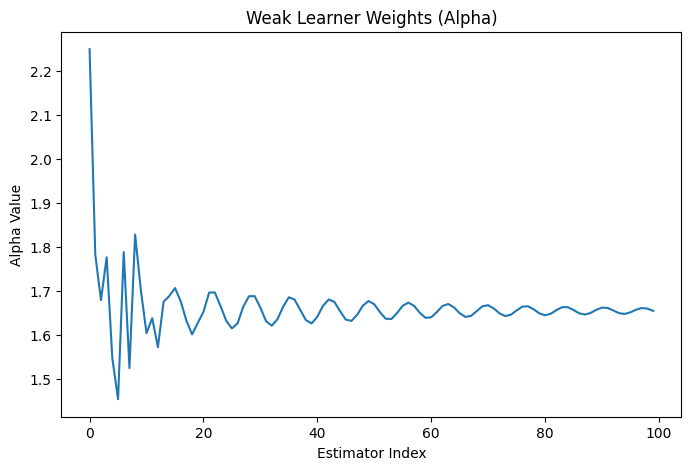

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(alpha_values)
plt.title("Weak Learner Weights (Alpha)")
plt.xlabel("Estimator Index")
plt.ylabel("Alpha Value")
plt.show()

**Expected Output (Zoo Dataset)**

Because features are clear binary rules:

Training Accuracy → ~100%

Testing Accuracy → 90–100%

Strong class separation

Few stumps dominate (higher alpha)